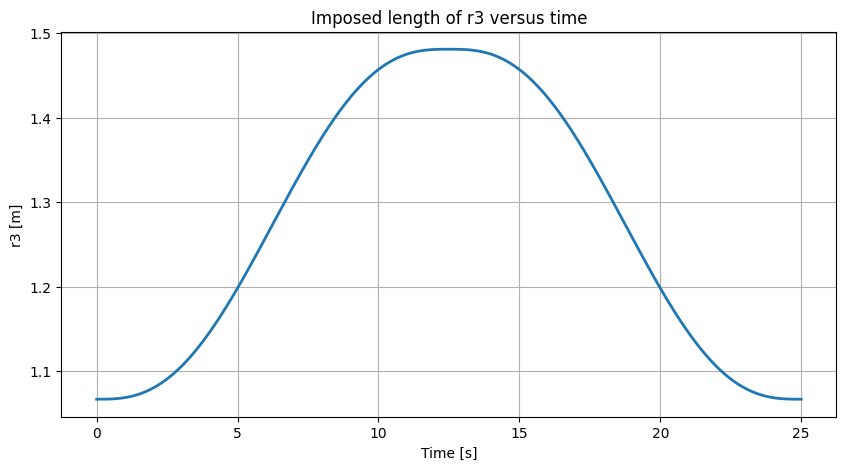

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# ==========================================================
# PARAMETERS
# ==========================================================

deg45 = np.pi / 4

r2  = 1.0
r1  = 0.3
r4r = 1.0
r6l = 0.3

r4l = r6l * (3 + 8*np.sqrt(2)) / 17
r4  = r4r + r4l

r11 = 0.3
r7  = 0.3

r8  = r2 + 0.6*np.cos(deg45)
r6r = r8 - r6l

r5 = np.sqrt(
    (r4 - r6r)**2
    + (r11*np.cos(deg45))**2
)

r9r = 0.45
r9l = 0.3
r9  = r9r + r9l

# ==========================================================
# FIXED POINTS
# ==========================================================

A = np.array([0.0, 0.0])
C = A + r1*np.array([np.cos(deg45), np.sin(deg45)])
B = (A + C) / 2

# ==========================================================
# INITIAL ANGLES
# angles définis de gauche à droite
# ==========================================================

phi2_init  = 0.0
phi3_init  = None
phi4_init  = 0.0
phi5_init  = None
phi6_init  = 0.0
phi7_init  = -deg45
phi8_init  = 0.0
phi11_init = deg45

# r9 et r11 sont rigides ensemble
# initialement phi9 = -45° et phi11 = +45°
phi9_offset = -np.pi/2

r3_init = np.sqrt(
    (-r11/2*np.cos(deg45) + r6r)**2
    + (1.5*r11*np.cos(deg45))**2
)

phi5_init = np.arctan2(
    r11*np.cos(deg45),
    r4 - r6r
)

phi3_init = -np.arctan2(
    1.5*r11*np.cos(deg45),
    -r11/2*np.cos(deg45) + r6r
)

# ==========================================================
# TIME
# ==========================================================

t_begin = 0.0
t_end   = 25.0
Ts      = 0.05

t = np.arange(t_begin, t_end + Ts, Ts)
N = len(t)

# ==========================================================
# IMPOSED r3 MOTION
# ==========================================================

r3_max = 1.481
dx = r3_max - r3_init
T = t_end - t_begin

def quintic_out_and_back(t, x0, dx, T):
    x = np.zeros_like(t, dtype=float)

    # aller : r3 augmente de x0 vers x0 + dx
    mask1 = (t >= 0) & (t <= T)
    tau1 = t[mask1] / T
    s1 = 10*tau1**3 - 15*tau1**4 + 6*tau1**5
    x[mask1] = x0 + dx*s1

    # retour : r3 diminue de x0 + dx vers x0
    mask2 = (t > T) & (t <= 2*T)
    tau2 = (t[mask2] - T) / T
    s2 = 10*tau2**3 - 15*tau2**4 + 6*tau2**5
    x[mask2] = x0 + dx*(1 - s2)

    x[t < 0] = x0
    x[t > 2*T] = x0

    return x

r3 = quintic_out_and_back(t, r3_init, dx, T/2)

# ==========================================================
# PLOT r3(t)
# ==========================================================

plt.figure(figsize=(10, 5))
plt.plot(t, r3, linewidth=2)
plt.xlabel("Time [s]")
plt.ylabel("r3 [m]")
plt.title("Imposed length of r3 versus time")
plt.grid(True)
plt.show()

# ==========================================================
# HELPERS
# ==========================================================

def unit(phi):
    return np.array([np.cos(phi), np.sin(phi)])

# ==========================================================
# SYSTEM
#
# Unknowns:
# phi2, phi3, phi4, phi5, phi6, phi7, phi8, phi11
#
# phi9 is not constant:
# phi9 = phi11 + phi9_offset
# ==========================================================

def system_equations(x, r3_k):

    phi2, phi3, phi4, phi5, phi6, phi7, phi8, phi11 = x

    phi9 = phi11 + phi9_offset

    # r4 : E/D -> C
    D = C - r4r * unit(phi4)
    E = C - r4  * unit(phi4)

    # r3 : F -> B
    F = B - r3_k * unit(phi3)

    # r11 : K -> D
    K = D - r11 * unit(phi11)
    M11 = D - (r11/2) * unit(phi11)

    # r9 : I/J -> M11
    J = M11 - r9r * unit(phi9)
    I = M11 - r9  * unit(phi9)

    # r6 : J -> F -> G
    G = J + (r6l + r6r) * unit(phi6)

    # r7 : H -> G
    H = G - r7 * unit(phi7)

    # Closures
    eq_EF = F - (E + r5 * unit(phi5))
    eq_KA = A - (K + r2 * unit(phi2))
    eq_JF = F - (J + r6l * unit(phi6))
    eq_HI = I - (H - r8 * unit(phi8))

    return np.concatenate([eq_EF, eq_KA, eq_JF, eq_HI])

# ==========================================================
# SOLVE POSITIONS
# ==========================================================

phi2  = np.zeros(N)
phi3  = np.zeros(N)
phi4  = np.zeros(N)
phi5  = np.zeros(N)
phi6  = np.zeros(N)
phi7  = np.zeros(N)
phi8  = np.zeros(N)
phi11 = np.zeros(N)

x_guess = np.array([
    phi2_init,
    phi3_init,
    phi4_init,
    phi5_init,
    phi6_init,
    phi7_init,
    phi8_init,
    phi11_init
])

for k in range(N):

    sol, info, ier, msg = fsolve(
        lambda x: system_equations(x, r3[k]),
        x_guess,
        full_output=True,
        maxfev=3000
    )

    residual = np.linalg.norm(system_equations(sol, r3[k]))

    if ier != 1 and residual > 1e-6:
        print(f"Attention convergence frame {k}")
        print(msg)
        print("residual =", residual)

    phi2[k], phi3[k], phi4[k], phi5[k], phi6[k], phi7[k], phi8[k], phi11[k] = sol

    x_guess = sol.copy()

# ==========================================================
# MECHANISM POINTS
# ==========================================================

def mechanism_points(k):

    phi9 = phi11[k] + phi9_offset

    D = C - r4r * unit(phi4[k])
    E = C - r4  * unit(phi4[k])

    F = B - r3[k] * unit(phi3[k])

    K = D - r11 * unit(phi11[k])
    M11 = D - (r11/2) * unit(phi11[k])

    J = M11 - r9r * unit(phi9)
    I = M11 - r9  * unit(phi9)

    G = J + (r6l + r6r) * unit(phi6[k])
    H = G - r7 * unit(phi7[k])

    return A, B, C, D, E, F, G, H, I, J, K, M11

# ==========================================================
# ANIMATION
# ==========================================================

plt.ioff()

fig, ax = plt.subplots(figsize=(9, 7))

index_vec = np.arange(0, N, 5, dtype=int)

x_left   = -2
x_right  =  1
y_bottom = -0.1
y_top    =  2.4

def update(frame_idx):

    k = index_vec[frame_idx]

    ax.clear()
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(x_left, x_right)
    ax.set_ylim(y_bottom, y_top)
    ax.grid(True)

    ax.set_xlabel("[m]")
    ax.set_ylabel("[m]")
    ax.set_title(f"Positions - frame {k} - t = {t[k]:.2f} s")

    A_, B_, C_, D, E, F, G, H, I, J, K, M11 = mechanism_points(k)

    ax.plot([A_[0], B_[0], C_[0]],
            [A_[1], B_[1], C_[1]],
            "-o", linewidth=3, label="r1")

    ax.plot([B_[0], F[0]],
            [B_[1], F[1]],
            "-o", linewidth=2, label="r3")

    ax.plot([C_[0], D[0], E[0]],
            [C_[1], D[1], E[1]],
            "-o", linewidth=2, label="r4l + r4r")

    ax.plot([E[0], F[0]],
            [E[1], F[1]],
            "-o", linewidth=2, label="r5")

    ax.plot([K[0], A_[0]],
            [K[1], A_[1]],
            "-o", linewidth=2, label="r2")

    ax.plot([K[0], M11[0], D[0]],
            [K[1], M11[1], D[1]],
            "-o", linewidth=2, label="r11")

    ax.plot([M11[0], J[0], I[0]],
            [M11[1], J[1], I[1]],
            "-o", linewidth=2, label="r9l + r9r")

    ax.plot([J[0], F[0], G[0]],
            [J[1], F[1], G[1]],
            "-o", linewidth=2, label="r6")

    # r7 : H -> G
    ax.plot(
        [H[0], G[0]],
        [H[1], G[1]],
        "-o",
        linewidth=2,
        label="r7"
    )

    # r8 : I -> H
    ax.plot(
        [I[0], H[0]],
        [I[1], H[1]],
        "-o",
        linewidth=2,
        label="r8"
    )

    points = {
        "A": A_,
        "B": B_,
        "C": C_,
        "D": D,
        "E": E,
        "F": F,
        "G": G,
        "H": H,
        "I": I,
        "J": J,
        "K": K
    }

    for name, point in points.items():
        ax.text(point[0] + 0.02, point[1] + 0.02, name, fontsize=10)

    ax.legend(loc="upper right", fontsize=8)

    return []

ani = FuncAnimation(
    fig,
    update,
    frames=len(index_vec),
    interval=50,
    blit=False
)

plt.close(fig)

display(HTML(ani.to_jshtml()))